# Replication of Section 5.2 (No Mutations)

Basener and Sanford falsely claim that they present the "results of a numerical simulation of Eq. ([3.2](https://link.springer.com/article/10.1007/s00285-017-1190-x#Equ8))." We will establish that they have substituted the desired results, calculated according to a simple formula, for the actual results, which they neglect to report. Furthermore, the actual results are quite different from the desired results. In concrete terms, they obtained their data by running Basener's [Realistic Mutation-Selection Modeling](https://people.rit.edu/wfbsma/evolutionary%20dynamics/EvolutionaryModel.html) software with the "mutation distribution type" set to `NoneExact` instead of to `None`. The results of the `None` "simulation" should be close to the results of the `NoneExact` formulaic calculation. But, as we shall see, there is a large discrepancy&nbsp;&mdash; in fact a bias in favor of the kind of results that Basener and Sanford hoped to report.

Note that the description of results in Section 5.2, "[Simulation with No Mutations and a Long Time-Span](https://link.springer.com/article/10.1007/s00285-017-1190-x#Sec15)," begins in Section 5.1, "[Simulation with No Mutations and a Short Time-Span
](https://link.springer.com/article/10.1007/s00285-017-1190-x#Sec14)."  Equation 3.2 of the article, mentioned above, is

\begin{equation*}
\frac{\text{d}P_i}{\text{d}t} = \sum_j \underbrace{b_j\, f_{ij}\, P_j}_{\text{births}} - \underbrace{d_i\, P_i}_{\text{deaths}}, \tag{3.2}
\end{equation*}

where the factors $b_i,$ $f_{ij},$ and $d_i$ are constant parameters of the system. Briefly, the organisms in a population are of a finite number of types. The equation gives the instantaneous rate of change in the frequency $P_i$ of type $i$ in the population. The change in frequency is due to births and deaths, with mutation generally causing some of the births to differ in type from their parents. The fraction of the births to parents of type $j$ that are of type $i$ is $f_{ij}.$
What Basener and Sanford refer to as "numerical simulation of Eq. ([3.2](https://link.springer.com/article/10.1007/s00285-017-1190-x#Equ8))" is iterative application of the equation at discrete steps in time, as though it were a difference equation instead of a differential equation. That is,

\begin{equation*}
    P_{t+1,i} \leftarrow P_{ti} + \sum_j b_j\, f_{ij}\, P_{tj} - d_i\, P_{ti}, \tag{1}
\end{equation*}


for $t = 1, 2, \ldots, T,$ with initial frequencies $P_{0i}$ as given below. This is what Basener's software does, **except** when "mutation distribution type" is set to `NoneExact`.

In the case of no mutation, all offspring are identical in type to their parents, which is to say that $f_{ii} = 1$ and $f_{ij} = 0$ for all $j \neq i.$ Then Equation (3.2) reduces to Equation ([3.1](https://link.springer.com/article/10.1007/s00285-017-1190-x#Equ7)) of the article,

\begin{align*}
\frac{\text{d}P_i}{\text{d}t} 
    &=  b_i\, P_i - d_i\, P_i \\
    &= m_i\, P_i, \tag{3.1}
\end{align*}

where the Malthusian growth factor $m_i = b_i - d_i.$ Given the frequency $P_{0,i}$ of type $i$ in the initial population, Equation (3.1) has the solution

\begin{equation}
P_{ti} = P_{0,i} \exp(t \cdot m_i) \tag{2}
\end{equation}

for all times $t \geq 0.$ What Basener's code does in the case of `NoneExact` is simply to calculate the solution directly: 
```javascript
if (mt == "NoneExact") 
    Psolution[t][i] = Psolution[0][i] * Math.exp(t * m[i]);
```

There can be no argument on this point. The question is how we can know that Basener and Sanford presented results of the formulaic calculation (`NoneExact`) rather than results of an iterated update of frequencies (`None`), when the results for the two cases should be similar. The answer is that the results are quite different. Rather than alert readers (including reviewers) to the fact that their code had failed a basic test of correctness, Basener and Sanford misreported the desired results as the actual results.

It is easy to account for the difference in results. First note that Basener and Sanford denominate time in years. We derive from Equation (2) a rule for annual update of the frequency of type $i$ in the population,

\begin{equation*}
P_{t+1,i} \leftarrow P_{ti} \exp(m_i)
\end{equation*}

for $t = 1, 2, \ldots, T.$ The result of $T$ applications of this rule, with initial frequency $P_{0,i},$ is precisely the frequency $P_{Ti}$ of Equation (2). Now we put Basener's annual update rule (Equation 1) in a similar form:

\begin{equation*}
P_{t+1,i} \leftarrow P_{ti} (1 + m_i)
\end{equation*}

for $t = 1, 2, \ldots, T.$ This makes it clear that Basener approximates $\exp(m_i)$ with $1 + m_i,$ and that the approximation error accumulates multiplicatively. After $t$ applications of Basener's annual update rule, the result differs from the desired result (the analytic solution of the differential equation) by a factor of

\begin{equation*}
\epsilon_t = \left[ \frac{1 + m_i}{\exp(m_i)} \right]^t. \tag{3}
\end{equation*}

To establish that we have a correct account of the discrepancy in actual and desired results, we will apply the error correction factors $\epsilon_t^{-1}$ to the output of Basener's code for the `None` iteration, and then show that the corrected output is very close to the output for the `NoneExact` evaluation of Equation (2).

## Load the results of `None` and `NoneExact` runs

**To display an animation below, you must run this cell first.**

In [15]:
%matplotlib notebook
%run ../Code/bs.py

with gzip.open('../Basener_Sanford_Data/bs5_2desired.pickled.gz') as f:
    desired_data = pickle.load(f)
with gzip.open('../Basener_Sanford_Data/bs5_2actual.pickled.gz') as f:
    actual_data = pickle.load(f)

desired = WrappedBS(desired_data, 'Reported (NoneExact)')
actual = WrappedBS(actual_data, 'Unreported (None)')

## Correct the results of iterated update of frequencies (`None`)

First we observe that the maximum absolute relative error is quite large.

In [2]:
maximum_absolute_relative_error(actual, desired)

0.9999999155688493

We multiply the results of the iterated update of frequencies (`None`) by the correction factors (reciprocals of Equation 3), and then verify that all of the corrected results are close to the corresponding desired results (`NoneExact`). Note that `np.outer()` is the outer product. For the sake of precision, we multiply the logarithmic correction factors for a single step of the iteration by each of the times `t`, and then exponentiate to get the correction factors.

In [3]:
m = desired_data['m']
t = np.arange(desired_data['numYears'])
n_years = t[-1]
log_single_step_correction = m - np.log(1 + m)
correction = np.exp(np.outer(t, log_single_step_correction))
maximum_absolute_relative_error(actual * correction, desired)

4.063416270128073e-13

The adjusted frequencies are identical to the formulaically calculated frequencies in the 13 most-significiant digits. Thus the error in Basener's iterative application of the differential equation (Equation 3.1 of the article) in discrete time follows our prediction (Equation 3). Our success in correcting the errors decreases over time, due to an unavoidable accumulation of numerical error in iterative application of the annual update rule.

<IPython.core.display.Javascript object>


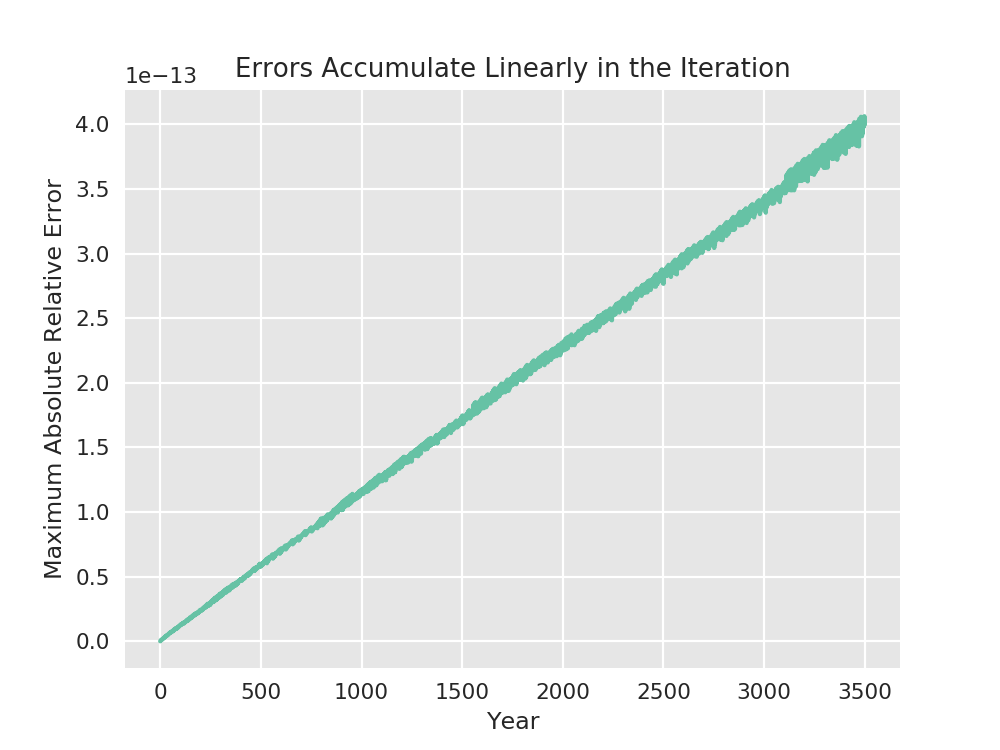

Text(0.5,0,'Year')

In [4]:
errors = [maximum_absolute_relative_error(actual[n] * correction[n], desired[n]) for n in range(len(desired))]
fig, ax = plt.subplots()
ax.plot(errors)
ax.set_title('Errors Accumulate Linearly in the Iteration')
ax.set_ylabel('Maximum Absolute Relative Error')
ax.set_xlabel('Year')

Now we plot the correction factors for the frequencies resulting from 3500 iterations of Basener's annual update rule, and observe that the errors are in fact huge.

<IPython.core.display.Javascript object>


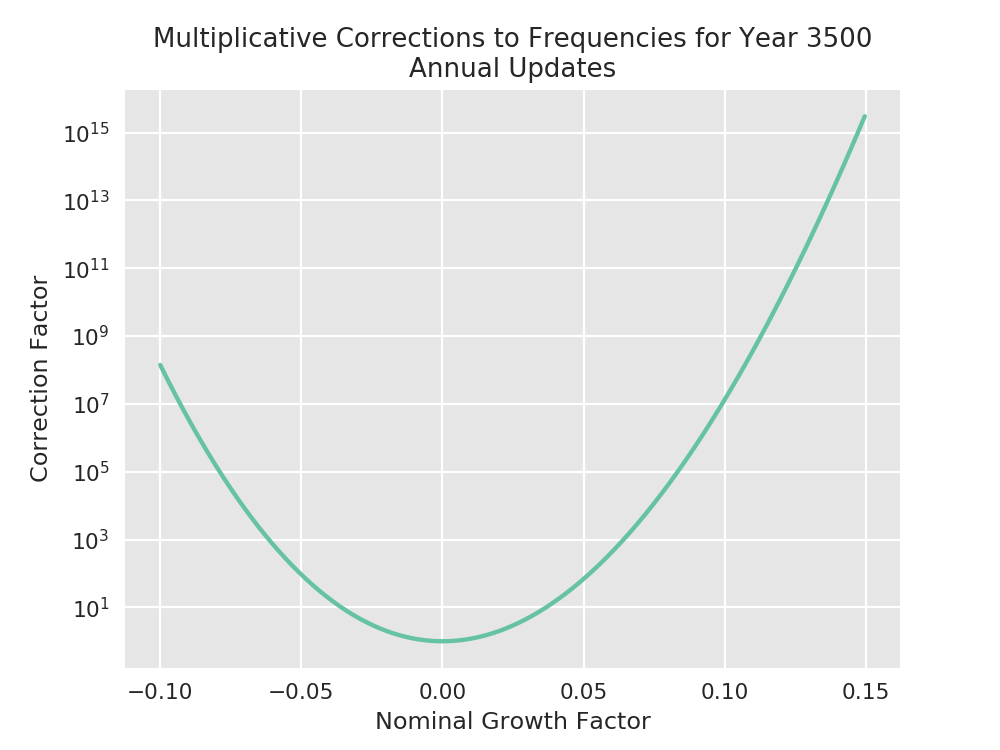

In [5]:
def plot_corrections(subtitle, correction, scale):
    fig = plt.figure()
    title = 'Multiplicative Corrections to Frequencies for Year 3500'
    title += '\n' + subtitle 
    ax = fig.gca()
    ax.set_title(title)
    ax.set_ylabel('Correction Factor')
    ax.set_xlabel('Nominal Growth Factor')
    ax.plot(m, correction)
    ax.set_yscale(scale)
    return fig
fig = plot_corrections('Annual Updates', correction[-1], 'log')

The annual growth factors are generally too great in magnitude for Basener's approximation of $\exp(m_i)$ with $1 + m_i$ to be good. With monthly updates, the annual growth factors are divided by 12, and the errors in the final year are greatly reduced, though there are 12 times as many iterations.

<IPython.core.display.Javascript object>


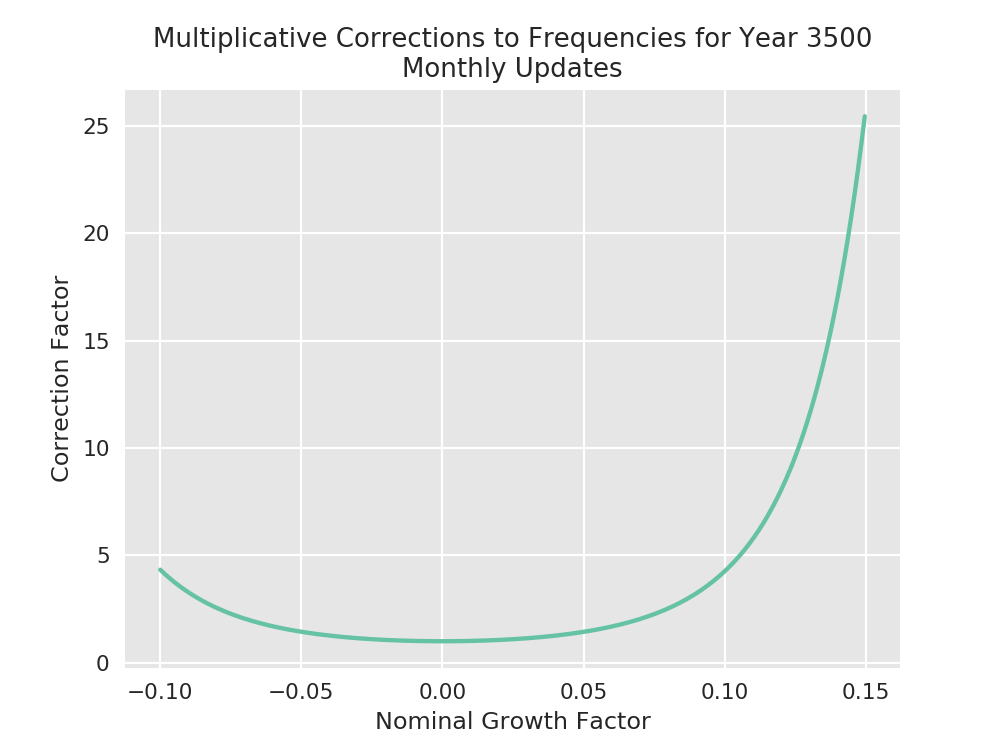

In [6]:
monthly_correction = np.exp(12 * 3500 * (m/12 - np.log(1 + m/12)))
fig = plot_corrections('Monthly Updates', monthly_correction, 'linear')

## Replicate the formulaic calculation of desired results (`NoneExact`)

The initial distribution of (unit) frequency over the growth factors is a discretized normal distribution with mean 0.044 and standard deviation 0.005. Frequencies are set to zero for growth factors differing from the mean by more than 11.2 standard deviations. The significance of the `approximate` parameter is explained below.

In [16]:
n_factors = desired_data['numIncrements'] + 1
initial = GaussianFactors(n_factors, mean=0.044, std=0.005, crop=11.2, approximate=True)
growth_factors = initial.growth_factors()

I have not followed Basener in excluding the upper endpoint of the interval of Malthusian growth factors. That is, we have one more of the factors than he does. All of the other growth factors match his exactly.

In [8]:
np.array_equal(growth_factors[:-1], m)

True

Now we verify that our `initial` frequency distribution closely approximates the initial `desired` frquency distribution.

In [9]:
maximum_absolute_relative_error(initial[:-1], desired[0])

8.881784197001252e-16

As explained below, Basener has normalized the initial frequency distribution inaccurately, and we have not. We obtain a closer match by scaling our initial frequencies by the (accurate) sum of the desired initial frequencies:

In [20]:
initial.p *= fsum(desired[0])
maximum_absolute_relative_error(initial[:-1], desired[0])

4.440892098500626e-16

We generate the matrix `P` of solutions (our Equation 2) to the differential equation given by Basener and Sanford in Equation (3.2). Note that `np.outer` is the outer product. When verifying that we have matched Basener's output, we must exclude the last column of `P`, as a consequence of including an extra growth factor.

In [21]:
P = initial * np.exp(np.outer(t, growth_factors))
maximum_absolute_relative_error(P[:, :-1], desired)

7.771561172376096e-16

## Replicate the iterated annual update of frequencies (`None`)

In my Python code, the frequencies of growth factors in the population reside in an instance of the class `Population`, which supplies an `annual_update` method. The method does not use the approximation $\exp(x) \approx 1 + x$ that Basener's update rule does. However, the `BS_Population` subclass of `Population` overrides the `annual_update` method with a version that does use the approximation. It furthermore is equipped to perform multiple updates per year. We will establish that iterated update of a `BS_Population` instance, restricted to one update per year, produces the unreported results for "mutation distribution type" of `None`. But first we show that iterated annual updates of a `Population` instance, without approximation, produce the desired results (`NoneExact`).

In [22]:
no_mutations = EffectsDistribution()
accurate = Evolution(Population(initial, no_mutations), n_years=n_years)
maximum_absolute_relative_error(accurate[:, :-1], desired)

5.484501741648273e-13

Again, there is an unavoidable accumulation of numerical error in 3500 applications of the annual update rule.

<IPython.core.display.Javascript object>


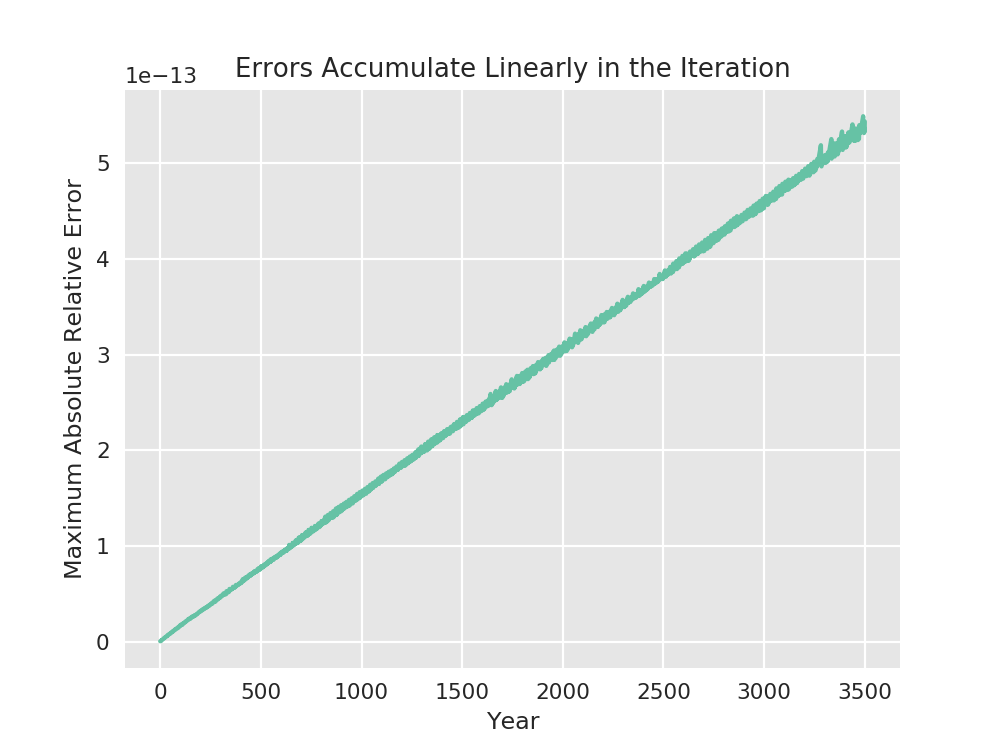

Text(0.5,0,'Year')

In [23]:
errors = [maximum_absolute_relative_error(accurate[n, :-1], desired[n] / fsum(desired[0]))
              for n in range(len(desired))]
fig, ax = plt.subplots()
ax.plot(errors)
ax.set_title('Errors Accumulate Linearly in the Iteration')
ax.set_ylabel('Maximum Absolute Relative Error')
ax.set_xlabel('Year')

Now we replace the `Population` instance with a `BS_Population` instance, and reproduce the actual results of Basener's iterated annual update of the frequencies (`None`). Note that we are as precise in replicating the actual results of iterating Basener's annual update rule as in generating the desired results with an accurate annual update rule.

In [24]:
inaccurate = Evolution(BS_Population(initial, no_mutations), n_years=n_years)
maximum_absolute_relative_error(inaccurate[:, :-1], actual)

1.0480505352461478e-13

As mentioned above, the `annual_update` method of a `BS_Population` instance can do multiple updates per year. We have calculated already the error correction factors for frequencies in year 3500 when updates are done monthly. Now we verify that applying the corrections to the results of monthly updates gives a close approximation to the desired results (`NoneExact`).

In [25]:
monthly = Evolution(BS_Population(initial, no_mutations, n_updates_per_year=12), n_years=3500)
maximum_absolute_relative_error(monthly[-1, :-1], desired[-1])

0.7627722157939855

In [26]:
maximum_absolute_relative_error(monthly[-1, :-1] * monthly_correction, desired[-1])

5.905720357191058e-12

Note that there is a greater accumulation of numerical error in this case because there are 12 times as many iterations of the monthly update as there are of the annual update.

## Compare the actual (`None`) and desired (`NoneExact`) results

Here we generate a graphical comparison of the unreported results of iterated annual updates (`None`) to the misreported results of evaluting the solution to the differential equation (`NoneExact`). 

The default display is a static plot of the last frame of an animation. If you are connected to a Jupyter server, then you should run the cell below with `nframes` set to a positive integer. The only one of the preceding cells that you need to have run is the very first. Animation is slow, so I recommend starting with 10 frames, and then deciding whether you care to see more.

<IPython.core.display.Javascript object>


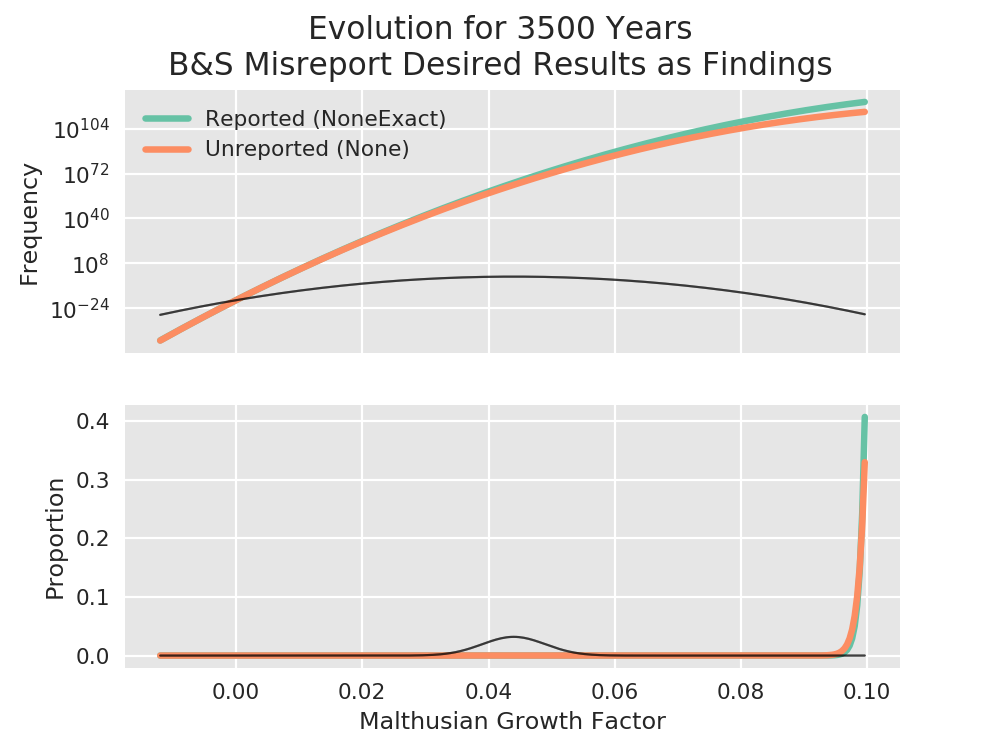

In [27]:
c = CompareProcesses([desired, actual])
c.set_subtitle('\nB&S Misreport Desired Results as Findings')
c.animate(nframes=0, duration=5000)

Note that the interval of Malthusian growth factors on display excludes elements that are initially assigned frequencies of zero. (In the absence of mutation, if the frequency of a type is initially zero, then the frequency of that type is zero forevermore.) 

Comparing [Figure 4](https://media.springernature.com/original/springer-static/image/art%3A10.1007%2Fs00285-017-1190-x/MediaObjects/285_2017_1190_Fig4_HTML.gif) of the article to the population proportions in the final frame of the animation, it is clear that Basener and Sanford present the analytic solution of a differential equation (`NoneExact`) when they claim to "present a simulation." Furthermore, the figure indicates that the mean fitness in year 750 is 0.063. By direct inspection of the output of Basener's code, we can determine that the figure was generated using the desired results, rather than the actual results of the "simulation" (`None`) that Basener and Sanford are supposed to have presented.

In [28]:
actual_data['meanFitness'][750], desired_data['meanFitness'][750]

(0.061661383741808434, 0.06274999999999756)

## A closer look at the initial frequency distribution

** This needs its own notebook. **

Basener and Sanford apparently used the same initial frequency distribution in all cases, as they claim in the article:

```javascript
var mean = 0.044;
var stdev = 0.005;
var numStDev = 11.2;

GaussianMultiplicativeTerm = 1 / (stdev * Math.sqrt(2 * Math.PI));
// Correct error: last iteration assigns to memory out of bounds
for (i = 0; i < numIncrements /* + 1 */; i++) { 
    P[i] = GaussianMultiplicativeTerm * Math.exp(-0.5 * Math.pow((m[i] - mean) / stdev, 2));
    if (m[i] < minFitness) {
        P[i] = 0
    };
    if (m[i] > maxFitness) {
        P[i] = 0
    };
}
```

The distribution `P` is not normalized, and the initial frequency distribution `Psolution[0]` is normalized inaccurately:

```javascript   
s = 0;
for (i = 0; i < numIncrements; i++) {
    s = s + P[i]
}

// snip
for (var i = 0; i < numIncrements; i++) {
    Psolution[0][i] = P[i] / s;
    // snip
}
```

(Interestingly, there is no need for multiplication by the constant `GaussianMultiplicativeTerm` with this approach.) We have access to both `P` and `Psolution` in the output of [BS.js](../Code/BS.js), so we may check the normalization using the accurate `fsum` in the Python math package.

In [ ]:
unnormed = actual_data['P']
normed = actual_data['Psolution'][0]
s = 0.0
for term in unnormed:
    s += term
fsum(unnormed) / s, fsum(normed)

Thus we have established that the initial frequencies do not sum to 1, and also have produced an account of *why* they do not sum to 1. Correcting the normalization, we gain about one digit of precision from the outset. 

In [ ]:
renormed = unnormed / fsum(unnormed)
(maximum_absolute_relative_error(initial[:-1], normed), 
 maximum_absolute_relative_error(initial[:-1], renormed))

We redo the calculation of the initial distribution in order to make the steps explicit. In the end, we obtain a distribution that is *exactly* equal to the distribution we used above. To match the results of Basener and Sanford, we must must approximate the probability mass of the subinterval centered on point `m[i]` as the product of the probability density at `m[i]` and the length `delta` of the subinterval.

In [ ]:
gaussian = stats.norm(0.044, 0.005)
delta = (m[-1] - m[0]) / (len(m) - 1)
p = gaussian.pdf(m) * delta
p[abs(m - 0.044) / 0.005 > 11.2] = 0
p /= fsum(p)
np.array_equal(p, initial[:-1]) # exactly the same results?

In [ ]:
maximum_absolute_relative_error(p_alt, renormed)

With an accurate calculation of the probability mass for each subinterval, essentially taking the difference of the cumulative distribution function at the upper and lower endpoints (my implementation also makes use of the survival function, which is more accurate than the cumulative distribution function in the upper tail of the distribution), the errors in year 0 are much greater than any we have seen in replication of 3500-year runs.

In [ ]:
approx_off = GaussianFactors(n_factors, crop=11.2, approximate=False)
maximum_absolute_relative_error(approx_off[:-1], unnormed/fsum(unnormed))

To be explicit, changing the value of `approximate` from `False` to `True`, while holding all else the same, greatly improves the fit of the initial frequency distribution in Basener's computation.

In [ ]:
approx_on = GaussianFactors(n_factors, crop=11.2, approximate=True)
maximum_absolute_relative_error(approx_on[:-1], unnormed/fsum(unnormed))

Even if we do the same operations that Basener does, we do not obtain exactly the same results.

In [ ]:
mean = 0.044
stdev = 0.005
GaussianMultiplicativeTerm = 1 / (stdev * np.sqrt(2 * np.pi))
d = GaussianMultiplicativeTerm * np.exp(-0.5 * np.power((m - mean) / stdev, 2))
d[abs(m - mean) / stdev > 11.2] = 0
maximum_absolute_relative_error(d, unnormed)

## Check of internal consistency

In [ ]:
assert actual_data['numYears'] == desired_data['numYears']
assert actual_data['numIncrements'] == desired_data['numIncrements']
assert actual_data['Psolution'].shape == desired_data['Psolution'].shape
assert len(actual_data['Psolution']) == actual_data['numYears']
assert len(actual_data['Psolution'].T) == actual_data['numIncrements']
assert np.array_equal(actual_data['m'], desired_data['m'])
assert len(actual_data['m']) == actual_data['numIncrements']

assert np.array_equal(desired, desired_data['Psolution'])
assert np.array_equal(actual, actual_data['Psolution'])
assert np.array_equal(desired.growth_factors(), desired_data['m'])
assert np.array_equal(actual.growth_factors(), actual_data['m'])

assert np.array_equal(actual[0], desired[0])

print('All assertions are true')

## Conclusion

Basener and Sanford present the results of evaluating the analytic solution of a differential equation, and claim instead to have presented the results of a "simulation" (by which they mean iterated application of the differential equation in discrete time, as though it were a difference equation). The unreported results of the iteration are not close to the analytic solution. Correcting the error is trivial: reduce the Malthusian growth factors in magnitude, and increase the number of iterations. Basener and Sanford surely would have seen the error, had they bothered with a sanity check of their code. Instead of correcting the iteration, they reported as its output the output that it failed to produce. It just so happens that the error biases the iteration in favor of growth factors close to zero (see Figure 1, above). Irrespective of whether Basener and Sanford purposefully introduced the bias to obtain the sort of results that they wanted to report, the bias in fact serves their purpose.